# Visualizing Data using t-SNE

Replication of van der Maaten and Hinton (2008), *Visualizing Data using t-SNE*, JMLR 9.

t-SNE is a non-linear dimensionality-reduction method designed for visualization: it
converts pairwise distances into probabilities and places points in two dimensions so that
the local neighborhood structure of the high-dimensional data is preserved, using a
heavy-tailed Student-t kernel in the low-dimensional space to avoid crowding. We reproduce
the paper's signature result on handwritten digits: t-SNE produces a 2-D map with cleanly
separated digit clusters, far clearer than the linear PCA projection. We quantify this with
a nearest-neighbor accuracy computed in each 2-D embedding.

In [1]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

In [2]:
digits = load_digits()
X, y = digits.data, digits.target              # 1797 samples of 8x8 handwritten digits
print("data", X.shape, "classes", len(np.unique(y)))

data (1797, 64) classes 10


In [3]:
Z_pca  = PCA(n_components=2).fit_transform(X)
Z_tsne = TSNE(n_components=2, perplexity=30, init="pca", random_state=0).fit_transform(X)
print("embeddings:", Z_pca.shape, Z_tsne.shape)

embeddings: (1797, 2) (1797, 2)


In [4]:
# Quantify how well each 2-D embedding preserves class structure (5-NN accuracy).
def knn_acc(Z): return cross_val_score(KNeighborsClassifier(5), Z, y, cv=5).mean()
print(f"5-NN accuracy in PCA-2D  : {knn_acc(Z_pca)*100:.1f}%")
print(f"5-NN accuracy in t-SNE-2D: {knn_acc(Z_tsne)*100:.1f}%")

5-NN accuracy in PCA-2D  : 60.3%
5-NN accuracy in t-SNE-2D: 97.6%


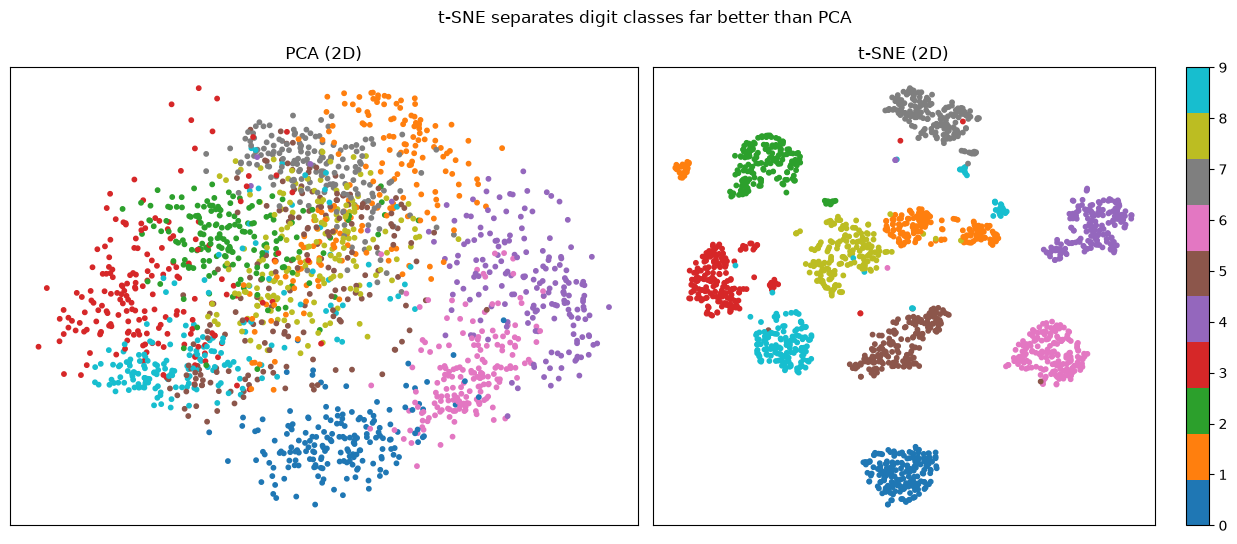

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
for A, Z, ttl in [(ax[0], Z_pca, "PCA (2D)"), (ax[1], Z_tsne, "t-SNE (2D)")]:
    sc = A.scatter(Z[:,0], Z[:,1], c=y, cmap="tab10", s=10); A.set_title(ttl); A.set_xticks([]); A.set_yticks([])
fig.colorbar(sc, ax=ax[1], ticks=range(10))
plt.suptitle("t-SNE separates digit classes far better than PCA"); plt.tight_layout(); plt.show()